<h2>LOAD MODELS<h2>

In [5]:
import numpy as np
from PIL import Image
import cv2
import os
import zipfile
import tempfile
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import BinaryIoU
from tensorflow.keras import backend as K

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

# Load U-Net (Segmentation)
unet = load_model(
    '../models/brain_tumor_unet.keras', 
    custom_objects={
        'dice_loss': dice_loss, 
        'dice_coef': dice_coef,
        'iou': BinaryIoU(target_class_ids=[1], threshold=0.5, name='iou')
    }
)

# Load ResNet50 (Classification)
# Load pretrained (ResNet50)
import keras
from keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Rebuild model
resnet50 = ResNet50(weights='imagenet', input_shape=(224,224,3), include_top=False)

resnet50.trainable = True

for layer in resnet50.layers[:140]:
    layer.trainable = False

model_classification = Sequential()
model_classification.add(resnet50)
model_classification.add(GlobalAveragePooling2D())
model_classification.add(Dense(256, activation='relu'))
model_classification.add(Dropout(0.5))
model_classification.add(Dense(256, activation='relu'))
model_classification.add(Dense(4, activation='softmax'))
model_classification.load_weights('../models/brain_tumor_classification_weights.h5')

<h2>LOAD DATA<h2>

In [6]:
def load_split(base_dir, split):
    images_dir = os.path.join(base_dir, split, 'images')
    X, labels = [], []  # ← removed y (masks)

    for subfolder in sorted(os.listdir(images_dir)):
        sub_img_dir = os.path.join(images_dir, subfolder)

        if not os.path.isdir(sub_img_dir): continue

        for fname in sorted(os.listdir(sub_img_dir)):
            if not fname.lower().endswith(('.png', '.jpg', '.jpeg', '.tif')): continue

            if subfolder == 'no_tumor':
                label = 3
            else:
                label = int(subfolder) - 1  # ← use subfolder name, not filename

            img = Image.open(os.path.join(sub_img_dir, fname)).convert('RGB').resize((224, 224))

            X.append(np.array(img))
            labels.append(label)

    return np.array(X), np.array(labels)  # ← removed y

In [7]:
BASE_DIR = '../data/figshare_braintumor_split'
TRAIN_PATH = os.path.join(BASE_DIR, 'train', 'images', '1')
MASK_PATH = os.path.join(BASE_DIR, 'train', 'masks', '1')

In [8]:
X_train, y_train = load_split(BASE_DIR, 'train')
X_val, y_val = load_split(BASE_DIR, 'val')
X_test, y_test = load_split(BASE_DIR, 'test')

# Normalize pixel values to [0, 1]
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3220, 224, 224, 3)
y_train shape: (3220,)
X_val shape: (334, 224, 224, 3)
y_val shape: (334,)
X_test shape: (910, 224, 224, 3)
y_test shape: (910,)


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_train)
y_train_enc = le.transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

from sklearn.utils import class_weight

# Calculate weights based on the distribution of your labels
weights = class_weight.compute_class_weight('balanced', 
                                            classes=np.unique(y_train_enc), 
                                            y=y_train_enc)
class_weights = dict(enumerate(weights))

print("Classes:", le.classes_)

Classes: [0 1 2 3]


In [10]:
import numpy as np

# Binarize masks + add channel dimension
y_train_mask = np.expand_dims((y_train > 127).astype(np.float32), axis=-1)
y_val_mask   = np.expand_dims((y_val > 127).astype(np.float32), axis=-1)
y_test_mask  = np.expand_dims((y_test > 127).astype(np.float32), axis=-1)

print("New mask shapes:")
print("Train:", y_train_mask.shape)
print("Val:", y_val_mask.shape)
print("Test:", y_test_mask.shape)

New mask shapes:
Train: (3220, 1)
Val: (334, 1)
Test: (910, 1)


<h2>EVALUATE<h2>

Classification model

In [16]:
from sklearn.metrics import accuracy_score
y_pred = model_classification.predict(X_test)
accuracy = accuracy_score(y_test, np.argmax(y_pred, axis=1))

print("Accuracy score:", accuracy)
print("Accuracy score:", accuracy)

29/29 [==============================] - 2s 55ms/step
Accuracy score: 0.8285714285714286
Accuracy score: 0.8285714285714286


              precision    recall  f1-score   support

  Meningioma       0.65      0.59      0.62       164
      Glioma       0.76      0.79      0.77       292
   Pituitary       0.87      0.89      0.88       174
    No Tumor       0.98      0.97      0.97       280

    accuracy                           0.83       910
   macro avg       0.81      0.81      0.81       910
weighted avg       0.83      0.83      0.83       910



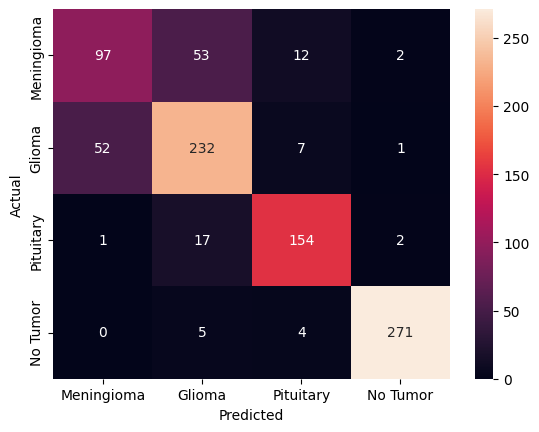

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ['Meningioma', 'Glioma', 'Pituitary', 'No Tumor']

print(classification_report(y_test, np.argmax(y_pred, axis=1), target_names=class_names))

cm = confusion_matrix(y_test, np.argmax(y_pred, axis=1))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()